In [97]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

# metrics

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import brier_score_loss

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

from sklearn.utils import resample


import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback

#preprocessing 
from tensorflow.keras.preprocessing import image


import sys
from copy import deepcopy

import kagglehub


This version uses preferred variable names (df__, formula__) and produces a reordered, cleaned DataFrame that matches our formula structure.

In [98]:
def reorder_and_clean_dmatrices(df__, formula__):
    """
    Reorder and clean DataFrame columns returned by dmatrices()
    according to the formula string.

    Steps:
    - Reorder columns to match formula sequence
    - Remove [T.True] suffix from categorical variables
    - Replace ':' with '*' in interaction terms
    """

    # Extract terms from formula
    terms = formula__.split('~')[1].split('+')
    terms = [t.strip() for t in terms]

    # Mapping categorical variables to dummy names
    mapping = {
        "MRD": "MRD[T.True]",
        "GR": "GR[T.True]",
        "BS": "BS[T.True]",
        "HW": "HW[T.True]",
        "AC": "AC[T.True]",
        "PAREA": "PAREA[T.True]",
        "FSS": "FSS[T.True]",
        "FSU": "FSU[T.True]"
    }

    ordered_cols = ["Intercept"]

    for term in terms:
        if "*" in term:  # interaction
            left, right = term.split("*")
            left, right = left.strip(), right.strip()
            if right in mapping:
                right = mapping[right]
            col_name = f"{left}:{right}"
            ordered_cols.append(col_name)
        else:  # main effect
            if term in mapping:
                ordered_cols.append(mapping[term])
            else:
                ordered_cols.append(term)

    # Reindex DataFrame
    df_reordered = df__[ordered_cols]

    # Clean column names
    df_reordered.columns = (
        df_reordered.columns
        .str.replace(r"\[T\.True\]", "", regex=True)  # remove [T.True]
        .str.replace(":", "*", regex=False)           # replace : with *
    )

    return df_reordered

In [99]:
path = os.path.join(os.getcwd(), 'DataSet', 'Housing.csv')
df = pd.read_csv(path)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True)
print(df_encoded.columns.values)

df_encoded.columns = ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA', 'FSS', 'FSU']
df = df_encoded
print(df.shape,'\n',df.columns)

formulas_singal_line = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS + FSU + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS + AR*FSU + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS + BD*FSU + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS + BT*FSU + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS + ST*FSU + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS + PARK*FSU'
formulas_two_line    = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS + FSU'
print(f'len formulas_singal_line {len(formulas_singal_line)} & len formulas_two_line {len(formulas_two_line)}')

y_single_sol,X_single_sol = dmatrices(formula_like  = formulas_singal_line,data=df, return_type='dataframe')
X_single_sol = reorder_and_clean_dmatrices(df__ = X_single_sol, formula__ = formulas_singal_line)
y_two_line_sol,X_two_line_sol = dmatrices(formula_like  = formulas_two_line,data=df, return_type='dataframe')
X_two_line_sol = reorder_and_clean_dmatrices(df__ = X_two_line_sol, formula__ = formulas_two_line)
print(f'y_single_sol shape {y_single_sol.shape} X_single_sol shape {X_single_sol.shape}') 
print(f'y_two_line_sol shape {y_two_line_sol.shape} X_two_line_sol shape {X_two_line_sol.shape}')
print(f'X_single_sol : {type(X_single_sol)} X_two_line_sol:{type(X_two_line_sol)}')

standard_scaler = StandardScaler()
min_max_scaler  = MinMaxScaler(feature_range=(0,1))

X_scaled_std_scal_single_line = standard_scaler.fit_transform(X_single_sol)
X_scaled_min_max_scal_single_line = min_max_scaler.fit_transform(X_single_sol)

X_scaled_std_scal_two_line = standard_scaler.fit_transform(X_two_line_sol)
X_scaled_min_max_scal_two_line = min_max_scaler.fit_transform(X_two_line_sol)


['price' 'area' 'bedrooms' 'bathrooms' 'stories' 'parking' 'mainroad_yes'
 'guestroom_yes' 'basement_yes' 'hotwaterheating_yes'
 'airconditioning_yes' 'prefarea_yes' 'furnishingstatus_semi-furnished'
 'furnishingstatus_unfurnished']
(545, 14) 
 Index(['PR', 'AR', 'BD', 'BT', 'ST', 'PARK', 'MRD', 'GR', 'BS', 'HW', 'AC',
       'PAREA', 'FSS', 'FSU'],
      dtype='object')
len formulas_singal_line 441 & len formulas_two_line 75
y_single_sol shape (545, 1) X_single_sol shape (545, 54)
y_two_line_sol shape (545, 1) X_two_line_sol shape (545, 14)
X_single_sol : <class 'pandas.core.frame.DataFrame'> X_two_line_sol:<class 'pandas.core.frame.DataFrame'>


## Ridge Regression: Bias–Variance Tradeoff:

#### Topic covered:

- What is the actual problem in OLS models when strong multicollinearity present in dataset.
- How the ride regressions come into picture and hoe=w we can understand this MSE


Problem with Least Squares OLS models:
Traditional least squares estimation (OLS) can produce unstable and inflated regression coefficients. Variance of coefficients is inflated, making estimates too large in magnitude and inconsistent across samples. This instability arises because least squares enforces unbiasedness, which can result in high variance and unreliable estimates.The Gauss–Markov theorem guarantees least squares has minimum variance among unbiased linear estimators, but this variance can still be very large. Result: wide confidence intervals and unstable point estimates.

**Ridge regression addresses** this by allowing bias in exchange for lower variance, leading to more stable and interpretable models. The key insight is that the mean squared error (MSE) of an estimator includes both variance and bias squared:

One way to alleviate this problem with Least Squares OLS modelsis to drop the requirement that the estimator of β be unbiased. Suppose that we can find a biased estimator of β, say $\hat {\beta }^{*}$, that has a **smaller variance** than the unbiased estimator $\hat {\beta }$ The mean square error of the estimator $\hat {\beta }^{*}$ is defined as

Mean Squared Error (MSE):

The quality of an estimator is measured by MSE:

$MSE(\hat {\beta }^{*})$ =  $Var({\beta }^{*})$ + $E((\hat{\beta}^*)) - (\beta)^2$     ---- (1)

$OR$

$\mathrm{MSE}(\hat {\beta }^*)=\mathrm{Var}(\hat {\beta }^*)+(\mathrm{bias\  in\  }\hat {\beta }^*)^2$ --(2)

Our Goel to achieve smaller variance.

MSE represents the expected squared distance between the estimator and the true parameter. Even if bias is introduced, if variance reduction is large enough, the overall MSE can be smaller than that of the unbiased estimator. This makes the biased estimator more reliable in practice.

Note that the **MSE** is just the **expected squared distance from** $\hat {\beta }^*$ to $\beta$. By allowing a small amount of bias in $\hat {\beta }^*$, the variance of $\hat {\beta }^*$ can be made small such that the **MSE** of $\hat {\beta }^*$ is less than the variance of the unbiased estimator $\hat {\beta }$. 

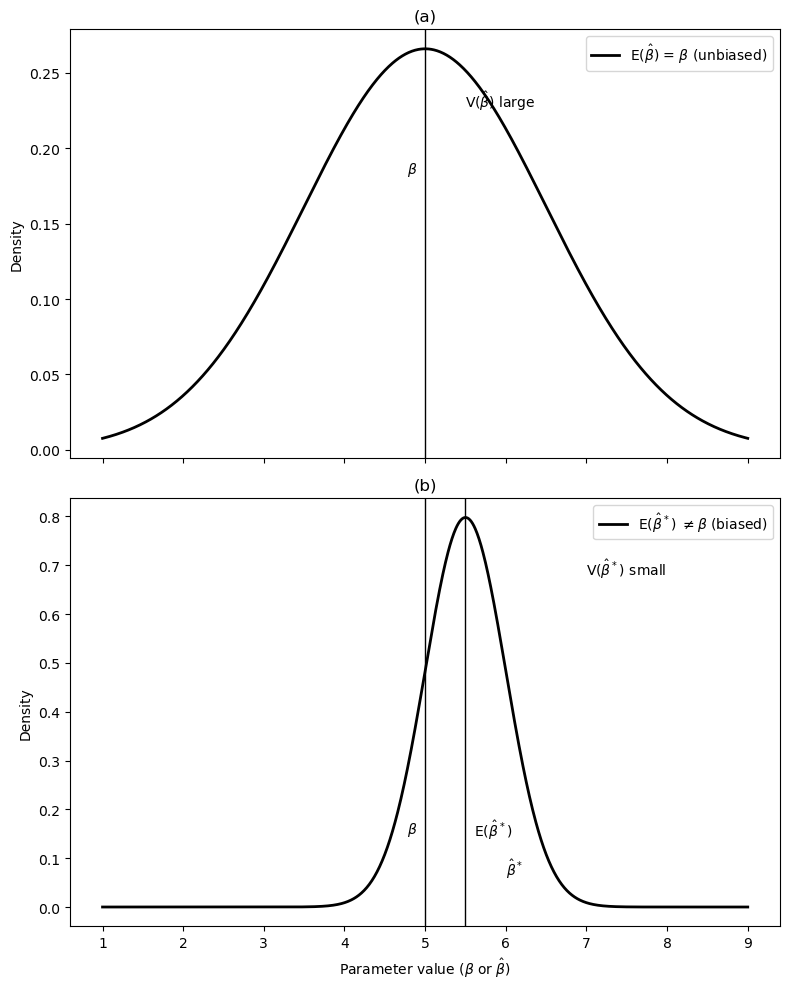

Figure b illustrates a situation where the variance of the biased estimator is considerably smaller than the variance of the unbiased estimator (Figure a). Consequently, confidence intervals on *\beta*  would be much narrower using the biased estimator. The small variance for the biased estimator also implies that $\hat {\beta }^*$ is a more stable estimator of $\beta$  than is the unbiased estimator $\hat {\beta }$.

A number of procedures have been developed for obtaining biased estimators of regression coefficients. One of these procedures is ridge regression.

***By accepting a small bias, Ridge regression can reduce variance enough to lower the overall MSE, making the estimator more reliable.***


## Understanding Ridge regressions procedure and how it's different from Least square equations:

Let regression model in matrix form:

$y=X\beta +\epsilon$ 

where
- y = vector of observed responses
- X = design matrix (predictors)
- $\beta$  = vector of regression coefficients
- $\epsilon$  = error term


least-squares normal equations

$X'X\hat {\beta }=X'y$           ----- ($i$)

least-squares estimator of $\beta $

$\hat {\beta }=(X'X)^{-1}X'y$    ---- ($ii$)

The least-squares method minimizes the sum of squared residuals:

$S(\beta )=(y-X\beta )'(y-X\beta )$    ------ ($iii$)

Derivations of equations i, ii, iii are out of scope for this Notebook.

A number of procedures have been developed for obtaining biased estimators of regression coefficients to mminized variance. One of these procedures is ridge regression.

#### Find  ridge estimator $\hat {\beta }_R$ from Lest square $eq^n$ :

$(X'X+kI)\hat {\beta }_R=X'y\quad$ ------($iv$)

$\hat {\beta }_R=(X'X+kI)^{-1}X'y\quad$  ----------($v$)

you can see clearly $eq^n$ iv & v are obtained form add const term $kI$ in $eq^n$ i & ii.

where $k\geq 0$ is a constant selected by the analyst. Note that when k=0 in $eq^n$ (iv) & (v), the ridge estimator is the least-squares estimator.

Equations (iv) & (v) obtained from least square equations by adding const term. So we can say that equations (iv & v) are the linear transformations of Lest-square estimations.

#### Ridge estimator is a linear transformation of the least-squares estimator:

$\hat {\beta }_R=(X'X+kI)^{-1}X'y$

$\hat {\beta }_R=(X'X+kI)^{-1}(X'X)\hat {\beta }$

$\hat {\beta }_R=Z_k\hat {\beta }$     ----- ($vi$)

Therefore, since $E(\hat {\beta }_R)=E(Z_k\hat {\beta })=Z_k\beta$ , $\hat {\beta }_R$ is a biased estimator of $\beta$. 


So the equations (vi) clearly explained Ridge regressions are the linear transform of Least square estimator.

#### Calculate varince of ridge regressions:

Variance of Least square estimator:

$\mathrm{Var}(\hat {\beta })=\sigma ^2(X'X)^{-1}$ 

Where
In ordinary least squares (OLS), the error variance is estimated as:

$\hat {\sigma }^2=\frac{1}{n-p}\sum _{i=1}^n\hat {\epsilon }_i^2=MS_{res}=\frac{SS_{res}}{n-1}$

$\hat {\sigma }^2=\frac{1}{n-p}\sum _{i=1}^n\hat {\epsilon }_i^2 = \frac{1}{n-p}\sum _{i=1}^n(y - \hat y)^2$

The covariance matrix of $\hat {\beta }_R$ (ridge regression estimator) is

$\mathrm{Var}(\hat {\beta }_R)=\sigma ^2(X'X+kI)^{-1}X'X(X'X+kI)^{-1}$ -----($vi$)

It shows how the variance depends on the regularization parameter $k$. Adding $kI$ stabilizes the inversion of $X'X$, reducing variance compared to ordinary least squares (OLS). This **reduction in variance** comes at the cost of introducing bias, which is the essence of the bias–variance tradeoff in ridge regression.
Or simply say s the regularization parameter $k$ increases, the variance term decreases.

#### Mean Square error of Ridge estimator:

$\mathrm{MSE}(\hat {\beta }_R)=\mathrm{Var}(\hat {\beta }_R)+(\mathrm{bias\  in\  }\hat {\beta }_R)^2$

$\mathrm{MSE}(\hat {\beta }_R)$ = $\sigma ^2\, \mathrm{Tr}\left[ (X'X+kI)^{-1}X'X(X'X+kI)^{-1}\right]$ + $(+k^{2}\beta ^{\prime }(\mathbf{X}^{\prime }\mathbf{X}+k\mathbf{I})^{-2}\beta)$

$\mathrm{MSE}(\hat {\beta }_R)$=$\sigma ^{2}\sum _{j=1}^{p}\frac{\lambda _{j}}{(\lambda _{j}+k)^{2}}+\frac{k^{2}\beta ^{\prime }\beta}{(\mathbf{X}^{\prime }\mathbf{X}+k\mathbf{I})^{2}}$  --- ($vii$)

where $\lambda _{1},\lambda _{2},...,\lambda _{p}$ are the eigenvalues of $\mathbf{X}^{\prime }\mathbf{X}$.

The first term on the right-hand side of (vii) is the sum of variances of the parameters in $\hat {\beta }_R$ and the second term is the square of the bias. If $k>0$, note that the bias in $\hat {\beta }_R$ increases with $k$. However, the variance decreases as $k$ increases. In using ridge regression we would.

#### Relations between  Mean Square error of Ridge estimator & $\hat \beta_R$:

The ridge trace, as $k$ is increased, some of the ridge estimates will vary dramatically. At some value of $k$, the ridge estimates $\hat {\beta }_R$ will *stabilize*. The objective is to select a reasonably small value of $k$ at which the ridge estimates $\hat {\beta }_R$ are stable. **This will produce a set of estimates with smaller MSE than the least-squares estimates.**


#### Explanations of eqn (viii):

We know that

$Multicollinearity \propto \frac{1}{\text{eigenvalue}(\lambda )}$

if $\lambda$ increased then Multicollinearity Reduced. Now from eqn(viii) first term

$\mathbf{MSE}(\^{\beta }_{R})\propto \frac{\lambda _{i}}{(\lambda _{i}+k)^{2}}$

if eigen value of $\lambda _{i}$ increase denomenator of above eqn do increase rapidly and MSE reduced. Also you notice notice if $k$ increase then MSE Also decrease.

Mean Squared Error (MSE): is a measure of the overall quality of an estimator or model prediction. It quantifies the average squared difference between the estimated values and the actual true values.

**A lower MSE indicates a better model.** 

As seen in the previous , 

$\mathbf{MSE}=\mathbf{Variance}+\mathbf{Bias}^{2}+\mathbf{IrreducibleError}$

**Variance**: How much the model predictions vary if we train the model on different data sets. High variance often means overfitting.

**Bias**: The difference between the expected (average) prediction of our model and the true value we are trying to predict. High bias often means underfitting.T

Ridge regression works by increasing the bias slightly in exchange for a significant reduction in variance, which usually leads to a lower overall MSE.

#### what happen $k$ = 0

All equations simply turn to OLS lest square models.

#### The OLS residual sum of square:

$SS_{\mathrm{Res}}=y'y-\hat {\beta }X'y$
- $y'y$: the inner product of the response vector with itself (essentially the sum of squared observed values).
- $\hat {\beta }X'y$: the fitted component, involving the estimated regression coefficients \hat {\beta } and the predictors X.

#### The OLS residual mean of square:

$MS_{\mathrm{Res}}=\frac{SS_{\mathrm{Res}}}{n-p}$
Where:
- $MS_{\mathrm{Res}}$: Residual mean square, an estimate of the variance of the error term.
- $SS_{\mathrm{Res}}$: Residual sum of squares, the total unexplained variation after fitting the model.
- $n$: Number of observations (sample size).
- $p$: Number of parameters estimated in the model (including the intercept).

### On the basis of OLS Residual sum of squares calculate ($SS{}_{Res}$) for the ridge estimator:

$SS_{Res}=(y-X\hat {\beta }_R)'(y-X\hat {\beta }_R)$

$SS_{Res}=(y-X\hat {\beta })'(y-X\hat {\beta })+(\hat {\beta }_R-\hat {\beta })'X'X(\hat {\beta }_R-\hat {\beta })$   -------   ($viii$)

Since the first term on the right-hand side ($viii$) is the residual sum of squares for the least-squares estimates $\hat {\beta }$, we see that as k increases, the residual sum of squares increases. 

Consequently, because the total sum of squares is fixed, $R^2$ decreases as $k$ increases.

👉 Therefore, the **ridge estimate will not necessarily provide the best 'fit' to the data**, but this should not overly concern us, since we are more interested in obtaining a stable set of parameter estimates. The ridge estimates may result in an equation that does a better job of predicting future observations than would least squares (although there is no conclusive proof that this will happen).

- Increasing k worsens the in-sample fit ($R^2$ decreases).
- But stability of parameter estimates improves.
- Ridge regression prioritizes predictive performance and stability over maximizing fit to the training data

#### Total Sum of Squares ($SS_T$): Same as OLS

$SS_T=\mathbf{y}'\mathbf{y}-\frac{\left( \sum _{i=1}^ny_i\right) ^2}{n}$
Where:
- $\mathbf{y}$ = vector of observed values $(y_1,y_2,\dots ,y_n)$
- $n$ = number of observations
- $\mathbf{y}'\mathbf{y}=\sum _{i=1}^ny_i^2$ (sum of squares of all observations)
- $\left( \sum _{i=1}^ny_i\right) ^2/n$ = correction term that accounts for the mean of y

#### Regressor Sum of Square:

$SS_R = SS_T - SS_{Res}$

#### Residual Mean Square Error (MSE₍Res₎):
The residual mean square error is obtained by dividing the residual sum of squares by the residual degrees of freedom:
MS_{\mathrm{Res}}=\frac{SS_{\mathrm{Res}}}{n-p}
- n: number of observations
- p: number of parameters (including intercept)
This gives an estimate of the variance of the error term under ridge regression.

Above formulas same as OLS.

#### Qus: What is expected value of SSres and MSres in ridge regressions?

In ridge regression, the expected value of the residual sum of squares (SS₍Res₎) is generally larger than in ordinary least squares (OLS), because ridge introduces bias into the coefficient estimates. Consequently, the expected residual mean square (MS₍Res₎ = SS₍Res₎/(n−p)) is also inflated compared to OLS. Unlike OLS, where $E[SS_{\mathrm{Res}}]=(n-p)\sigma ^2$, ridge regression does not yield an unbiased estimator of $\sigma ^2$.

Expected value of $SS_{res}$ Ordinary Least Squares (OLS) $E[MS_{\mathrm{Res}}]=\sigma ^2 (unbiased)$:

$E[SS_{\mathrm{Res}}]=(n-p)\sigma ^2$

$E[MS_{\mathrm{Res}}]=\sigma ^2$

This is because OLS residuals are orthogonal to the fitted values, and the estimator of variance is unbiased.

Expected value of $SS_{res}$ Ridge $E[MS_{\mathrm{Res}}]>\sigma ^2 (biased)$:

The expectation involves both variance and bias terms:

$E[SS_{\mathrm{Res}}]=(n-p)\sigma ^2+\mathrm{Bias\  Term}$

- The bias term arises because ridge shrinks coefficients toward zero.
- As $k\rightarrow 0$, ridge approaches OLS, so $E[SS_{\mathrm{Res}}]\rightarrow (n-p)\sigma ^2$.
- As $k\rightarrow \infty$ , coefficients shrink heavily, predictions collapse toward the mean, and $SS_{\mathrm{Res}}$ increases significantly

Thus, ridge regression inflates the expected residual sum of squares compared to OLS.

Residual Mean Square (MS₍Res₎):

$MS_{\mathrm{Res}}=\frac{SS_{\mathrm{Res}}}{n-p}$

- In OLS: unbiased estimator of $\sigma ^2$.
- In ridge: biased upward, because **shrinkage increases residual variance**.
- Therefore: $E[MS_{\mathrm{Res}}]>\sigma ^2$

- Ridge *reduces variance of coefficient* estimates but increases bias.
- **Impact on $SS_{Res}$**: More bias → larger residuals → higher expected SS₍Res₎.
- **Impact on $MS_{Res}$**: No longer unbiased for $\sigma ^2$; instead, it reflects both error variance and shrinkage bias.

#### Find appropriate value of $k$ (**ridge trace**):
Appropriate value of $k$ determined by inspection of the **ridge trace**. The **ridge trace** is a plot of the elements of $\hat {\beta }_R$ versus $k$ for values of $k$ usually in the interval $0–1$.

If multicollinearity is severe, the instability in the regression coefficients will be obvious from the ridge trace. As $k$ is increased, some of the ridge estimates will vary dramatically. 

At some value of $k$, the ridge estimates $\hat {\beta }_R$ will stabilize. The objective **ridge trace** is to select a reasonably small value of $k$ at which the ridge estimates $\hat {\beta }_R$ are stable.

Choosing k:

- The goal is to pick a small but positive k where coefficients are stable.
- Stability means reduced variance and more reliable predictions.
- This choice balances bias (introduced by ridge regression) with variance reduction.



Classical statistical tools such as F-tests, t-tests, hypothesis testing, and outlier detection using standardized or studentized residuals (e.g., Cook's distance) are not directly applicable in ridge regression. These diagnostics are valid in ordinary least squares (OLS) regression but lose interpretability when regularization is introduced.

To bridge this gap, ridge regression estimates can be computed using a transformation that recasts the problem into an OLS framework. This allows us to leverage OLS machinery while incorporating the ridge penalty.

## ridge regression estimates by using an OLS:

*Note: This method yet not verified in this notebook!!!*

The ridge regression estimates may be computed by using an ordinary least-squares by transformations 

${X}_{A}=\left[\begin{matrix}\mathbf{X}\\ \sqrt{k}\mathbf{I}_{p}\end{matrix}\right],\quad \mathbf{y}_{A}=\left[\begin{matrix}\mathbf{y}\\ \mathbf{0}_{p}\end{matrix}\right]$

where

- $\mathbf{X}$: Original $n\times p$ design matrix
- $\mathbf{y}$: Original $n\times 1$ response vector
- $k$: Ridge penalty (biasing parameter)
- $\mathbf{I_{\mathnormal{p}}}$: $p\times p$ identity matrix
- $\mathbf{0_{\mathnormal{p}}}$: $p\times 1$ zero vector


where $\sqrt{k}\mathbf{I}_{p}$ is a $p\times p$ diagonal matrix with diagonal elements equal to the square root of the biasing parameter, and $\mathbf{0}_{p}$ is a $p\times 1$ vector of zeros . The ridge estimates are computed as:

$\hat {\beta }_{R}=(\mathbf{X}_{A}^{\prime }\mathbf{X}_{A})^{-1}\mathbf{X}_{A}^{\prime }\mathbf{y}_{A}=(\mathbf{X}^{\prime }\mathbf{X}+k\mathbf{I}_{p})^{-1}\mathbf{X}^{\prime }\mathbf{y}$

Same as eqn ($v$)

Ridge regression "improves" upon OLS in situations where the OLS assumptions are violated, particularly when predictor variables are correlated or there are more predictors than observations. By accepting a small, controlled amount of bias (by adding the penalty term), the model achieves a larger reduction in variance, leading to a lower overall Mean Squared Error (MSE) and better predictive performance on unseen data.

## Calculations of R²,Adjusted R², RMES:

#### R² (Coefficient of Determination):

R² measures the proportion of variance in the dependent variable explained by the regression model.

$R^2=1-\frac{SS_{res}}{SS_{tot}}$

#### Adjusted R²

**Adjusted R²** accounts for the number of predictors in the model, penalizing for adding variables that don’t improve the model significantly.

$R_{adj}^2=1-\left( \frac{(1-R^2)(n-1)}{n-p-1}\right)$ 

Where:
- n = number of observations
- p = number of predictors (independent variables)
- R^2 = unadjusted coefficient of determinatio

#### Root Mean Squared Error (RMSE) for ridge regression:

$RMSE=\sqrt{\frac{SS_{\mathrm{Res}}}{n}}$
where:
- $SS_{\mathrm{Res}}$ explained above.
- $n$ is the number of observations,
- $\hat {\beta }_R=(X'X+kI)^{-1}X'y$ are the ridge estimates.
This is simply the square root of the mean squared error of residuals


In [100]:
def ridge_coeff__(X_regressor: np.ndarray, y: pd.Series, k: float) -> np.ndarray:
    """
    Compute ridge regression coefficients using closed-form solution:
    beta_R = (X'X + kI)^(-1) X'y
    -------
    beta_R : np.ndarray
        Ridge regression coefficients of shape (p,).
    """
    # Ensure numpy arrays
    X = np.asarray(X_regressor)
    #if isinstance(y, pd.Series):
    y = y.to_numpy().reshape(-1, 1)   # convert Series to column vector
    
    n, p = X.shape
    
    # Compute (X'X + kI)^(-1) X'y
    XtX = X.T @ X
    ridge_term = XtX + k * np.eye(p)
    ridge_inv = np.linalg.inv(ridge_term)
    beta_R = ridge_inv @ X.T @ y
    
    return beta_R.flatten()

In [101]:
def ridge_coefficients(X_regressor, y_dependent, k_values, fit_intercept=False, scale_coeffs=False):
    """
    Compute ridge regression coefficients for multiple k values.
    
    Parameters
    ----------
    X_regressor : numpy.ndarray
        Regressor matrix of shape (n, p)
    y_dependent : numpy.ndarray
        Dependent variable vector of shape (n,)
    k_values : list or array
        List of ridge penalty parameters
    fit_intercept : bool
        Whether to include an intercept term
    scale_coeffs : bool
        If True, apply StandardScaler to coefficients before returning
    
    Returns
    -------
    pd.DataFrame
        DataFrame with coefficients (scaled if enabled), columns = k values
    """
    n, p = X_regressor.shape
    
    # Add intercept if required
    if fit_intercept:
        X_regressor = np.hstack([np.ones((n, 1)), X_regressor])
        p += 1
    
    I = np.eye(p)
    coeffs = []
    '''    
    for k in k_values:
        XtX = X_regressor.T @ X_regressor
        XtY = X_regressor.T @ y___
        beta = np.linalg.inv(XtX + k * I) @ XtY
        coeffs.append(beta.flatten())
    '''
    for k in k_values:
        coeffs.append(ridge_coeff__(X_regressor = X_regressor, 
                                    y = y_dependent, 
                                    k = k))
    # Convert to array (p x len(k_values))
    coeffs = np.array(coeffs).T
    
    # Apply scaling if flag is True
    if scale_coeffs:
        scaler = StandardScaler()
        coeffs = scaler.fit_transform(coeffs)
    
    # Build DataFrame
    df_ridge = pd.DataFrame(coeffs, columns=k_values, index=[f"beta_{i}" for i in range(p)])
    return df_ridge

# ridge_penalty_param = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
ridge_penalty_param = list(range(10, 5001, 10)) #[5,10,50,100,250,500,850,1000]
ridef_coff = ridge_coefficients(X_regressor = X_scaled_std_scal_single_line, 
                   y_dependent = y_single_sol, 
                   k_values = ridge_penalty_param, 
                   fit_intercept=False,
                   scale_coeffs=False)

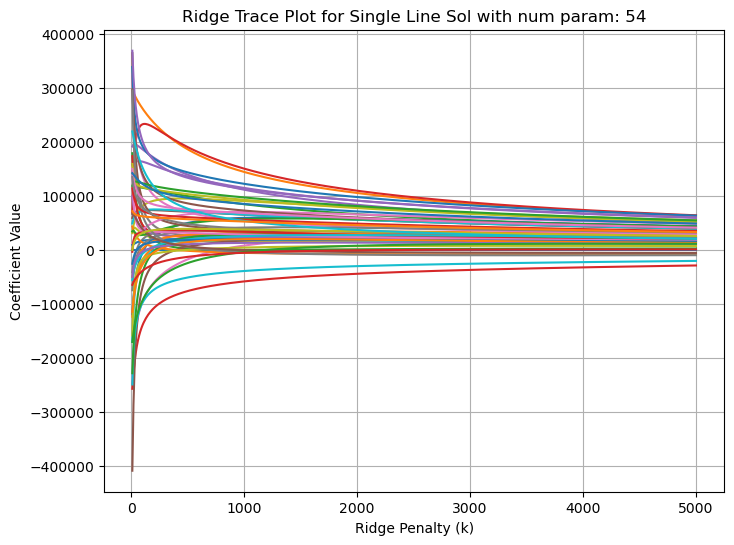

In [102]:
def plot_ridge_trace(riddge_coff_data, k_values):
    """
    Plot ridge trace: coefficients vs ridge penalty k.
    """
    plt.figure(figsize=(8, 6))
    for coeff in riddge_coff_data.index:
        plt.plot(k_values, riddge_coff_data.loc[coeff])
    
    plt.xlabel("Ridge Penalty (k)")
    plt.ylabel("Coefficient Value")
    plt.title(f"Ridge Trace Plot for Single Line Sol with num param: {riddge_coff_data.shape[0]}")
    plt.grid(True)
    plt.show()

plot_ridge_trace(riddge_coff_data = ridef_coff,
                 k_values = ridge_penalty_param)

In [103]:
type(ridef_coff)
ridef_coff_ser = ridef_coff.iloc[0]

In [104]:
def ridge_confidence_intervals(
    X_regressor: np.ndarray,
    y_dependent_var: pd.Series,
    beta_ridge: pd.Series,
    k: float,
    alpha: float = 0.05,
    n_bootstrap: int = 1000
):
    """
    Compute confidence intervals for Ridge regression coefficients.
    Returns
    -------
    pd.DataFrame
        DataFrame with coefficient estimates and confidence intervals:
        - 'Coefficient'
        - 'Analytical_CI_Lower'
        - 'Analytical_CI_Upper'
        - 'Bootstrap_CI_Lower'
        - 'Bootstrap_CI_Upper'
    """
    # Ensure y is numpy vector
    y = y_dependent_var.values.flatten()
    n, p = X_regressor.shape

    # Residuals and sigma^2
    resid = y - X_regressor @ beta_ridge.values
    sigma2 = np.mean(resid**2)

    # Analytical variance
    XtX = X_regressor.T @ X_regressor
    var_matrix = sigma2 * np.linalg.inv(XtX + k*np.eye(p)) @ XtX @ np.linalg.inv(XtX + k*np.eye(p))
    se = np.sqrt(np.diag(var_matrix))

    z_val = norm.ppf(1 - alpha/2)
    ci_lower_analytical = beta_ridge.values - z_val * se
    ci_upper_analytical = beta_ridge.values + z_val * se

    # Bootstrap confidence intervals
    boot_coefs = []
    for _ in range(n_bootstrap):
        Xb, yb = resample(X_regressor, y)
        # Ridge estimator formula directly
        beta_boot = np.linalg.inv(Xb.T @ Xb + k*np.eye(p)) @ (Xb.T @ yb)
        boot_coefs.append(beta_boot)
    boot_coefs = np.array(boot_coefs)

    ci_lower_boot = np.percentile(boot_coefs, 100*alpha/2, axis=0)
    ci_upper_boot = np.percentile(boot_coefs, 100*(1-alpha/2), axis=0)

    # Combine results
    results = pd.DataFrame({
        "Coefficient": beta_ridge.values,
        "Analytical_CI_Lower": ci_lower_analytical,
        "Analytical_CI_Upper": ci_upper_analytical,
        "Bootstrap_CI_Lower": ci_lower_boot,
        "Bootstrap_CI_Upper": ci_upper_boot
    }, index=beta_ridge.index)

    return results

# Extract the correct ridge coefficients for the selected penalty (k=2240)
#beta_ridge = ridef_coff[2240]

ci_df = ridge_confidence_intervals(
    X_regressor=X_scaled_std_scal_single_line,
    y_dependent_var=y_single_sol,
    beta_ridge=ridef_coff[2240],
    k=2240,
    alpha=0.05,
    n_bootstrap=500
)


In [105]:
def get_prediction(beta_ridge: pd.Series, X_regressor: np.ndarray, y: pd.Series):
    """
    OLS-style prediction function for Ridge regression.
    
    Parameters
    ----------
    beta_ridge : pd.Series
        Ridge regression coefficients (length p).
    X_regressor : np.ndarray
        Scaled design matrix (n x p).
    y : pd.Series
        Dependent variable (n,).
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - 'y_true' : actual values
        - 'y_pred' : predicted values
        - 'residuals' : y_true - y_pred
    """
    # Ensure y is numpy vector
    y_true = y.values.flatten()
    
    # Predictions
    y_pred = X_regressor @ beta_ridge.values
    
    # Residuals
    residuals = y_true - y_pred
    
    # Return DataFrame
    results = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "residuals": residuals
    })
    
    return results

ridge_optimized_penalty_param = [174.614, 2090,2231.6829,2140,2220, 2230,2240]

ridef_coff = ridge_coefficients(X_regressor = X_scaled_std_scal_single_line, 
                   y_dependent = y_single_sol, 
                   k_values = ridge_optimized_penalty_param, 
                   fit_intercept=False,
                   scale_coeffs=False)

pred_df = get_prediction(beta_ridge = ridef_coff.iloc[:,0], 
               X_regressor = X_scaled_std_scal_single_line, 
               y = y_single_sol)

In [106]:
ci_df.columns

Index(['Coefficient', 'Analytical_CI_Lower', 'Analytical_CI_Upper',
       'Bootstrap_CI_Lower', 'Bootstrap_CI_Upper'],
      dtype='object')

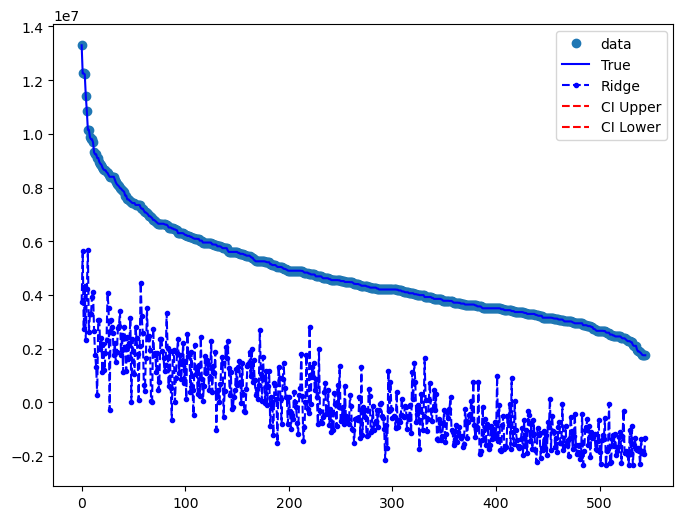

In [107]:
# Example plotting
def plot_ridge_predictions(x, y, pred_df, ci_df, bootstrapping=True):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(x, y, "o", label="data")
    ax.plot(x, pred_df["y_true"], "b-", label="True")
    ax.plot(x, pred_df["y_pred"], "b--.", label="Ridge")
    if bootstrapping:
        ax.plot(x, ci_df["Bootstrap_CI_Upper"].reindex(pred_df.index), "r--", label="CI Upper")
        ax.plot(x, ci_df["Bootstrap_CI_Lower"].reindex(pred_df.index), "k--", label="CI Lower")
    else:
        ax.plot(x, ci_df["Analytical_CI_Upper"].reindex(pred_df.index), "r--", label="CI Upper")
        ax.plot(x, ci_df["Analytical_CI_Lower"].reindex(pred_df.index), "r--", label="CI Lower")
    ax.legend(loc="best")
    plt.show()

# Ensure x and y have the same length
x = np.arange(pred_df.shape[0])  # x has the same length as pred_df
y = pred_df["y_true"].values     # Use y_true from pred_df for consistency

# Plot
plot_ridge_predictions(
    x=x,
    y=y,
    pred_df=pred_df,
    ci_df=ci_df,
    bootstrapping=False
)


In [108]:
def ridge_mse(X_regressor: np.ndarray, y_dependent_variable: pd.DataFrame, k_list: list):
    """
    Calculate MSE of Ridge regression estimator for given penalty parameters.
    
    Parameters
    ----------
    X_regressor : np.ndarray
        Scaled design matrix (n x p).
    y_dependent_variable : pd.DataFrame
        Response vector (n x 1).
    k_list : list
        List of ridge penalty parameters.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - 'Penalty' : ridge penalty parameter (k)
        - 'MSE'     : corresponding MSE value
    """
    # Ensure y is numpy vector
    y = y_dependent_variable.values.flatten()
    
    # OLS estimates
    XtX = X_regressor.T @ X_regressor
    XtY = X_regressor.T @ y
    beta_ols = np.linalg.pinv(XtX) @ XtY
    
    # Residuals and sigma^2 (OLS MSE of residuals)
    resid = y - X_regressor @ beta_ols
    sigma2 = np.mean(resid**2)
    
    # Eigen decomposition of XtX
    eigvals, _ = np.linalg.eigh(XtX)
    
    results = []
    for k in k_list:
        # First term: variance component
        var_term = sigma2 * np.sum(eigvals / (eigvals + k)**2)
        
        # Second term: bias component
        bias_term = (k**2) * (beta_ols @ beta_ols) / np.sum((eigvals + k)**2)
        
        mse_val = var_term + bias_term
        results.append((k, mse_val))
    
    # Convert to DataFrame
    mse_df = pd.DataFrame(results, columns=["Penalty", "MSE"])    
    return mse_df

def plot_ridge_mse(mse_df: pd.DataFrame, penalty_team: list = None):
    """
    Plot Penalty vs MSE with a marker at the optimal penalty.
    Also annotate penalties provided in penalty_team list with red arrows.
    
    Parameters
    ----------
    mse_df : pd.DataFrame
        DataFrame with columns ['Penalty','MSE'].
    penalty_team : list, optional
        List of penalty values to annotate on the plot.
    """
    plt.figure(figsize=(8,5))
    plt.plot(mse_df["Penalty"], mse_df["MSE"], marker="o", linestyle="-", color="blue")
    plt.xlabel("Ridge Penalty (k)")
    plt.ylabel("MSE")
    plt.title("Penalty vs MSE for Ridge Regression")

    # Highlight optimal penalty
    min_idx = mse_df["MSE"].idxmin()
    optimal_k = mse_df.loc[min_idx, "Penalty"]
    optimal_mse = mse_df.loc[min_idx, "MSE"]
    plt.axvline(x=optimal_k, color="red", linestyle="--", label=f"Optimal k = {optimal_k:.3f}")
    plt.scatter([optimal_k], [optimal_mse], color="red")
    plt.annotate(f"Optimal k = {optimal_k:.3f}",
                 xy=(optimal_k, optimal_mse),
                 xytext=(optimal_k*1.1, optimal_mse*1.05),
                 arrowprops=dict(facecolor="red", shrink=0.05, width=1.5))

    # Annotate penalty_team values with red arrows
    if penalty_team is not None:
        for i,p in enumerate(penalty_team):            
            if p in mse_df["Penalty"].values:
                mse_val = mse_df.loc[mse_df["Penalty"] == p, "MSE"].values[0]
                plt.scatter([p], [mse_val], color="green")
                plt.annotate(f"k={p}",
                             xy=(p, mse_val),
                             xytext=(p*1.1, (mse_val*5)),
                             arrowprops=dict(facecolor="red", shrink=0.05, width=1.5))

    plt.legend()
    plt.grid(True)
    plt.show()



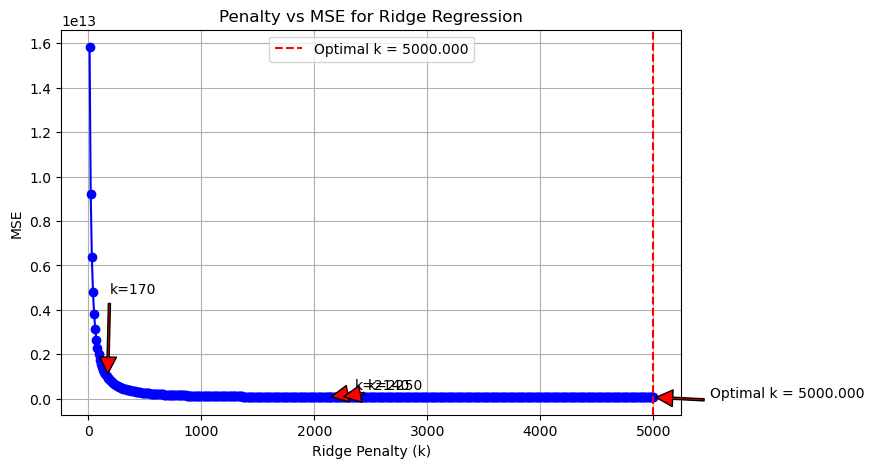

In [109]:
ridge_penalty_param__ = [174.614, 2090,2231.6829,2140,2220, 2230,2240]    
mse_df  = ridge_mse(X_regressor = X_scaled_std_scal_single_line, 
                   y_dependent_variable = y_single_sol, 
                   k_list = ridge_penalty_param
                   #k_list = ridge_penalty_param__
                   )

plot_ridge_mse(mse_df,[170,2140,2250])

## Methods for Choosing k:

Much of the **controversy concerning ridge regression centers around the choice of the biasing parameter $k$**. 

Hoerl and Kennard proposed an iterative procedure to determine an optimal biasing parameter $k$ that minimizes the mean squared error (MSE) of the regression coefficients.

**The Iterative Estimation's Procedure Algorithm:**

The method is based on the theoretical formula for \(k\) that minimizes the MSE of the ridge estimator.
Iterative Formulas for Choosing $k$ in Ridge Regression

Step1: Using the ordinary least squares estimator $\hat {\beta }$:

$k=\frac{p\hat {\sigma }^2}{\hat {\beta }'\hat {\beta }}$

Step2: Using the ridge estimator based on $k_0$, denoted $\hat {\beta }_R(k_0)$:

$k_1=\frac{p\hat {\sigma }^2}{\hat {\beta }_R(k_0)'\hat {\beta }_R(k_0)}$

Step3: Using the ridge estimator based on $k_1$, denoted $\hat {\beta }_R(k_1)$:

$k_2=\frac{p\hat {\sigma }^2}{\hat {\beta }_R(k_1)'\hat {\beta }_R(k_1)}$

Step4: Iterate until the value of $k$ stabilizes.

Notations:

Where: 
- $p$ is the number of parameters.
- ${\sigma }^{2}$ is the unbiased estimate of the error variance from the Ordinary Least Squares (OLS) model.
- $\hat {\beta }$: OLS coefficient vector.
- $\hat {\beta }_R(k$): ridge regression coefficient vector for penalty k

It’s a way of converging toward a more stable choice of the ridge penalty parameter.

#### Termination Condition for Iterative Procedure:

The iterative process for updating $k$ is terminated when the relative change between successive values exceeds a threshold:

$\frac{k_{j+1}-k_j}{k_j}>20T^{-1.3}$

- where:
  - $k_j$: current ridge penalty value.
  - $k_{j+1}$: next ridge penalty value.
  - $T$: a parameter (often related to sample size, iterations, or scaling factor depending on context).
  - The inequality ensures that the algorithm stops if the relative change in $k$ is too large compared to the tolerance defined by $20T^{-1.3}$

#### Compute T

$T=\frac{Tr(X^{\prime }X)^{-1}}{P}=\frac{\sum _{j=1}^{p}(1/\lambda _{i})}{p}$

where:
- X is a regressor matrix)
- $\mathrm{Tr}$ is the trace of a matrix,
- $\lambda _j$ are the eigenvalues of X'X,
- $p$ is the number of predictors (columns of X).



#### Hoerl and Kennard Method 1:

In [110]:
def ridge_estimator(X_regressor, y_dependent, k):
    """
    Compute ridge regression coefficients for given k.
    """
    # Ensure numpy arrays
    X_regressor = np.asarray(X_regressor)
    y_dependent = np.asarray(y_dependent).reshape(-1, 1)

    n, p = X_regressor.shape
    I = np.eye(p)
    XtX = X_regressor.T @ X_regressor
    XtY = X_regressor.T @ y_dependent
    beta = np.linalg.inv(XtX + k * I) @ XtY
    return beta.flatten()

def compute_T(X_regressor, tol=1e-12):
    """
    Compute T = Tr((X'X)^-1) / p
    using pseudo-inverse for stability.
    """
    X = np.asarray(X_regressor)
    n, p = X.shape
    
    # Compute X'X
    XtX = X.T @ X
    
    # Method 1: Direct trace of pseudo-inverse
    XtX_inv = np.linalg.pinv(XtX)   # <-- safer than np.linalg.inv
    T_trace = np.trace(XtX_inv) / p
    
    # Method 2: Using eigenvalues, avoid divide by zero
    eigenvalues = np.linalg.eigvals(XtX)
    inv_eigs = [1.0/l if abs(l) > tol else 0.0 for l in eigenvalues]
    T_eigen = np.sum(inv_eigs) / p
    
    return T_trace, T_eigen

def hoerl_kenn_iterative_k_selection(X_regressor, y_dependent,max_iter=100):
    """
    Iteratively compute k using Hoerl-Kennard-Baldwin method with stopping rule.
    """
    T1,T2 = compute_T(X_regressor)
    T = T1
    X_regressor = np.asarray(X_regressor)
    y_dependent = np.asarray(y_dependent)

    n, p = X_regressor.shape
    print(f"Samples {n} predictors {p}")
    # Initial OLS estimate using statsmodels
    ols_model = sm.OLS(y_dependent, X_regressor).fit()
    beta_ols = np.asarray(ols_model.params).reshape(-1, 1)
    #sigma2 = estimate_sigma2(X_regressor, y_dependent, beta_ols)
    sigma2  = ols_model.mse_resid
    # First k0
    k0 = ((p * sigma2) / (beta_ols.T @ beta_ols)).item()
    k_values = [float(k0)]
    
    for j in range(max_iter):
        beta_r = ridge_estimator(X_regressor, y_dependent, k_values[-1])
        k_next = (p * sigma2) / (beta_r.T @ beta_r)
        k_values.append(float(k_next))
        
        # Stopping condition
        rel_change = (k_next - k_values[-2]) / k_values[-2]
        if rel_change > 20 * (T ** -1.3):
            break
    
    return k_values




In [111]:
k_seq = hoerl_kenn_iterative_k_selection(X_regressor = X_scaled_std_scal_single_line, 
                              y_dependent = y_single_sol,                               
                              max_iter=10)
# Perform element-wise division
k_seq = [k / 2 for k in k_seq]
print("Sequence of k values:\n", k_seq, '\n', 'numpy array:\n', np.array(k_seq).reshape(-1, 1))

Samples 545 predictors 54
Sequence of k values:
 [174.61444071763918, 2231.6829958756243, 10100.577876778987, 73526.16120052425, 2669067.014394693, 3291529661.943227, 4996246018210657.0] 
 numpy array:
 [[1.74614441e+02]
 [2.23168300e+03]
 [1.01005779e+04]
 [7.35261612e+04]
 [2.66906701e+06]
 [3.29152966e+09]
 [4.99624602e+15]]


In [112]:
def ridge_hat_matrix(X_regressor: np.ndarray, k: float) -> np.ndarray:
    """
    Compute the ridge regression hat matrix H_k = X (X'X + kI)^(-1) X'.
    Returns
    -------
    H_k : np.ndarray
        Hat matrix of shape (n, n).
    """
    # Ensure X is numpy array
    X = np.asarray(X_regressor)
    
    # Dimensions
    n, p = X.shape
    
    # Compute (X'X + kI)^(-1)
    XtX = X.T @ X
    ridge_term = XtX + k * np.eye(p)
    ridge_inv = np.linalg.inv(ridge_term)
    
    # Hat matrix
    H_k = X @ ridge_inv @ X.T
    return H_k

#### Choosing k for Prediction Purposes (Mallows' C_k Statistic)

The methods of choosing k described thus far are focused on improving the estimates of the regression coefficients. If the model is to be used for prediction purposes, then it may be more appropriate to consider prediction-oriented criteria for choosing $k$.

Colin Mallows introduced the $C_{p}$ **statistic** as a tool for model selection in **OLS**, primarily to balance the trade-off between model bias and model variance. Since Ridge Regression introduces intentional bias to reduce variance, **Mallows' logic was extended** to create the $C_{k}$ statistic (sometimes called $C_{L}$).

The $C_{k}$ statistic allows you to evaluate which value of the penalty parameter $k$ produces the best predictive model.

Mallows (1973) modified the $C_p$ statistic to a $C_k$ statistic that can be used to determine $k$. He proposed plotting $C_k$ against $V_k$, where:

$C_k=\frac{SS_{\mathrm{Res}}(k)}{\hat {\sigma }^2}-n+2+2\, \mathrm{Tr}(XL)$

Where:
- $\mathrm{Tr}$ is the trace of a matrix
- $L=(X'X+kI)^{-1}X'$
- $SS_{Res}$: The Residual Sum of Squares for the ridge model with penalty $k (y-X\^{\beta }_{k})^{2}$. This is the functions of $k$. Suggested to that choose $k$ to minimized $C_k$. 
- $\hat \sigma^{2}$: The unbiased estimate of the error variance (usually taken from the full OLS model).
- $n$: The number of observations.

$V_k$:
- $V_k=1+\mathrm{Tr}(X'XL')$

Here, $SS_{\mathrm{Res}}(k)$ is the residual sum of squares as a function of $k$. The suggestion is to choose $k$ that minimizes $C_k$.

#### Hat Matrix $H_{k}$ & The Role of the Hat Matrix $H_{k}$:

$XL+X(X'X+kI)^{-1}X'=H_k$

This $H_k$ is the ridge regression hat matrix, equivalent to the hat matrix in **ordinary least squares** hat matrix but adjusted for the penalty $k$.

Look for small $C_{k}$ values: A good model will have a low $C_{k}$ value, indicating low prediction error.

Target $C_{k}\approx V_{k}$: Ideally, you look for a point where the $C_{k}$ value is close to the corresponding $V_{k}$ value. There is often a diagonal line drawn on the plot to help visualize this. Models near this line are considered relatively unbiased in estimating the true regression coefficients.


In [113]:
def compute_Ck_Vk_Hk(X_regressor, y_dependent, k_values, tol=1e-12):
    """
    Compute C_k, V_k, and H_k for a range of ridge penalty values.
    
    Parameters
    ----------
    X_regressor : numpy.ndarray
        Regressor matrix (n, p)
    y_dependent : numpy.ndarray
        Dependent variable vector (n,)
    k_values : list or array
        Ridge penalty values
    tol : float
        Tolerance for eigenvalue stability
    
    Returns
    -------
    results : dict
        Dictionary with keys 'Ck', 'Vk', 'Hk' (each a list for each k)
    """
    X__ = np.asarray(X_regressor)
    y__ = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X__.shape
    
    # OLS model for sigma^2 estimate
    ols_model = sm.OLS(y__, X__).fit()
    #sigma2_hat = np.mean(ols_model.resid**2)
    sigma2_hat = ols_model.mse_resid
    Ck_list, Vk_list, Hk_list,e_ik_list = [], [], [], []
    XtX = X__.T @ X__
    for k in k_values:        
        XtX_inv_k = np.linalg.pinv(XtX + k*np.eye(p))  # safer than inv
        
        # Define L and L'
        L = XtX_inv_k @ X__.T              # (p, n)
        LtL = L @ L.T          # (n, p)       
        
        # Ridge coefficients
        beta_r = XtX_inv_k @ (X__.T @ y__)
        
        # Residuals for ridge
        y_hat = X__ @ beta_r
        residuals = y__ - y_hat
        SS_res = (residuals.T @ residuals).item()  # safe scalar
        e_ik_list.append(residuals)
        # Compute C_k
        Ck = (SS_res / sigma2_hat) - n + 2 + 2 * np.trace(X__ @ L)
        Ck_list.append(Ck)
        
        # Compute V_k (correct formula using L')
        Vk = 1 + np.trace(XtX @ LtL)
        Vk_list.append(Vk)
        
        # Compute H_k
        # Hk = X__ @ L + X__ @ XtX_inv_k @ X__.T
        Hk = ridge_hat_matrix(X_regressor=X_regressor, k=k) 
        Hk_list.append(Hk)
    
    return {"Ck": Ck_list, "Vk": Vk_list, "Hk": Hk_list,"e_ik_list":e_ik_list}

def plot_Ck_Vk(Ck_list, Vk_list, k_values):
    """
    Plot C_k vs V_k for given k values.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(Vk_list, Ck_list, marker='o')
    #for i, k in enumerate(k_values):
    #    plt.text(Vk_list[i], Ck_list[i], f"k={k}", fontsize=8)
    
    plt.xlabel("V_k")
    plt.ylabel("C_k")
    plt.title("Mallows C_k vs V_k Plot")
    plt.grid(True)
    plt.show()

def plot_X_Ck_Vk(Ck_list, Vk_list, k_values, threshold=None, font_size=9):
    """
    Plot C_k vs V_k for given k values and annotate smaller C_k values.
    
    Parameters
    ----------
    Ck_list : list
        List of C_k values
    Vk_list : list
        List of V_k values
    k_values : list
        Ridge penalty values corresponding to C_k and V_k
    threshold : float, optional
        Annotate points where C_k <= threshold. If None, annotate the lowest 3 values.
    font_size : int, optional
        Font size for annotation text (default=9)
    """   
    
    plt.figure(figsize=(8, 6))
    plt.plot(Ck_list,Vk_list, marker='o', linestyle='-', color='blue')
    plt.xlabel("C_k")
    plt.ylabel("V_k")
    plt.title("Mallows C_k vs V_k Plot")
    plt.grid(True)
    
    # Decide which points to annotate
    if threshold is not None:
        indices_to_annotate = [i for i, ck in enumerate(Ck_list) if ck <= threshold]
    else:
        # Annotate the 3 smallest Ck values
        indices_to_annotate = np.argsort(Ck_list)[:3]
    for i in indices_to_annotate:
        print(f'k value for min C_k & V_k: {k_values[i]}')
    # Annotate selected points
    for i in indices_to_annotate:
        plt.annotate(f"k={k_values[i]}, Ck={Ck_list[i]:.2f}",
                     xy=(Vk_list[i], Ck_list[i]),
                     xytext=(Vk_list[i]+2, Ck_list[i] + 10),
                     textcoords='data',
                     ha='center',
                     fontsize=12,
                     arrowprops=dict(arrowstyle='->', color='red'))
    
    plt.show()



minum of C_k -27.64808149972826  minum of v_k 2.135987873249907
k value for min C_k & V_k: 2230
k value for min C_k & V_k: 2220
k value for min C_k & V_k: 2240


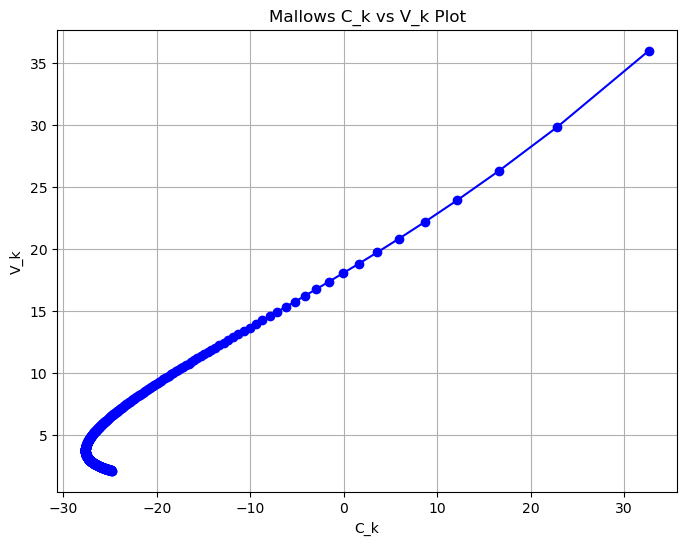

In [114]:
results_compute_Ck_Vk_Hk = compute_Ck_Vk_Hk(X_regressor = X_scaled_std_scal_single_line, 
                           y_dependent = y_single_sol, 
                           k_values    = ridge_penalty_param
                           )
print(f'minum of C_k',min(results_compute_Ck_Vk_Hk["Ck"]),' minum of v_k',min(results_compute_Ck_Vk_Hk["Vk"]))
plot_X_Ck_Vk(Ck_list  = results_compute_Ck_Vk_Hk["Ck"], 
           Vk_list  = results_compute_Ck_Vk_Hk["Vk"], 
           k_values = ridge_penalty_param
           )

#### Choosing optimal $k$ by use PRESS Ridge Procedure

The Ridge Hat Matrix $H_{k}$:The Ridge Hat matrix is defined in the text's equation as: 

$H_{k}=XL+X(X^{\prime }X+kI)^{-1}X^{\prime }$

(Note: The first term "$XL$" appears to be a typo in the original text/image content, as the standard formula is given by the rest of the expression).

This matrix maps the vector of observed responses $y$ to the vector of fitted values $\hat {y}_{k}$.

The text notes that $H_{k}$ is equivalent to the hat matrix in ordinary least squares when $k=0$. The diagonal elements $h_{ii,k}$ are the leverages, representing the influence of each observation on its own prediction.

The PRESS Ridge Procedure:

$PRESS$ stands for Prediction Error Sum of Squares. It is an out-of-sample validation statistic that estimates a model's predictive performance.

The image presents an approximation of the true $PRESS$ value for Ridge Regression:

$\mathrm{PRESS_{Ridge}}(k)=\sum _{i=1}^n\left( \frac{e_{i,k}}{1-h_{ii,k}}\right) ^2$

Where:

- $e_{i,k}$: $i^{th}$ residual (observed minus predicted value) for the model with penalty $k$.
- $h_{ii,k}$: diagonal element of the ridge hat matrix $H_k=X(X'X+kI)^{-1}X'$.
- Choose $k$ that minimizes $PRESS{}_{\mathrm{Ridge}}$.

#### Determining the optimal $k$:

The value of $k$ is chosen so as to minimize the calculated $\text{PRESS}_{\text{Ridge}}$ statistic. This value provides the best trade-off between the bias introduced by regularization and the reduction in variance, leading to better predictions on new data.

Note on Approximation The text points out that this formula is only an approximation of the exact PRESS value (Equation 2 in the image) that would be obtained by standard Leave-One-Out Cross-Validation (LOOCV). The approximation is computationally much faster because it avoids refitting the model $n$ times but works best when there are no highly influential data points (large leverages).

In [115]:
def compute_PRESS_ridge(X_regressor, y_dependent, k_values):
    """
    Compute PRESS_Ridge for a range of ridge penalty values.
    
    Parameters
    ----------
    X_regressor : numpy.ndarray
        Regressor matrix (n, p)
    y_dependent : numpy.ndarray
        Dependent variable vector (n,)
    k_values : list or array
        Ridge penalty values
    
    Returns
    -------
    press_list : list
        PRESS_Ridge values for each k
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape
    
    press_list = []
    XtX = X.T @ X
    for k in k_values:
        
        XtX_inv_k = np.linalg.pinv(XtX + k*np.eye(p))  # pseudo-inverse for stability
        
        # Hat matrix H_k
        #Hk = X @ XtX_inv_k @ X.T
        Hk = ridge_hat_matrix(X_regressor = X_regressor, k = k)
        # Ridge coefficients
        beta_r = XtX_inv_k @ (X.T @ y)
        
        # Residuals
        y_hat = X @ beta_r
        residuals = (y - y_hat).flatten()
        
        # Diagonal of H_k
        h_diag = np.diag(Hk)
        
        # PRESS_Ridge
        press_k = np.sum((residuals / (1 - h_diag))**2)
        press_list.append(press_k)
    
    return press_list

def plot_PRESS_ridge(k_values, press_list):
    """
    Plot PRESS_Ridge vs k.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, press_list, marker='o', linestyle='-')
    plt.xlabel("Ridge Penalty k")
    plt.ylabel("PRESS_Ridge")
    plt.title("PRESS_Ridge vs k")
    plt.grid(True)
    
    # Highlight the minimum PRESS
    min_idx = np.argmin(press_list)
    plt.scatter(k_values[min_idx], press_list[min_idx], color='red', zorder=5)
    optimal_k = k_values[min_idx]
    print(f"Optimal k = {optimal_k}")
    optimal_press = press_list[min_idx]
    plt.annotate(f"Optimal k = {optimal_k}",
                 xy=(optimal_k, optimal_press),
                 xytext=(optimal_k, optimal_press + 100),
                 textcoords='data',
                 ha='center',
                 fontsize=11,
                 arrowprops=dict(arrowstyle='->', color='red'))    
    plt.show()


Optimal k = 2140


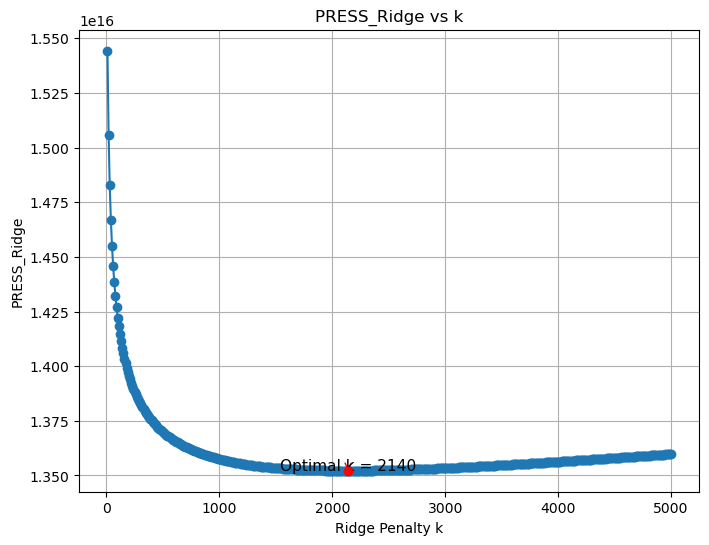

In [116]:
press_values = compute_PRESS_ridge(X_regressor = X_scaled_std_scal_single_line, 
                                   y_dependent = y_single_sol, 
                                   k_values    = ridge_penalty_param
                                   )

#for k, press in zip(ridge_penalty_param, press_values):
#    print(f"k={k}, PRESS_Ridge={press:.4f}")
plot_PRESS_ridge(k_values = ridge_penalty_param, 
                 press_list = press_values)

#### Generalized Cross‑Validation (GCV) in ridge regression.

In ridge regression, Generalized Cross-Validation (GCV) is an efficient statistical technique used to select the optimal regularization parameter $\lambda$ or $\alpha$. It acts as a computationally faster approximation of Leave-One-Out Cross-Validation (LOOCV), providing a reliable estimate of a model's predictive risk without needing to retrain the model for every single data point.

The primary goal of GCV is to balance the bias‑variance tradeoff. By finding the value of $\lambda$  that minimizes the $GCV$ score, you ensure the model is complex enough to capture patterns but simple enough to avoid overfitting.

The Smoother/Hat Matrix $GCV$ relies on the hat matrix $S_{\lambda }$ (also called the smoothing matrix), which maps the observed response values to the predicted values.

Rotation Invariance: Unlike some other cross‑validation methods, GCV is rotation‑invariant, meaning it remains consistent even if the coordinate system of the data is transformed.

Generalized Cross‑Validation (GCV) Score:

$GCV(\lambda )=\frac{\frac{1}{n}\sum _{i=1}^n(y_i-\hat {y}_i)^2}{\left( 1-\frac{1}{n}\, \mathrm{tr}(S_{\lambda })\right) ^2}$

Explanation
- $n$: number of data points.
- $\sum (y_i-\hat {y}_i)^2$: Residual Sum of Squares (RSS), measuring how far predictions are from actual values.
- $\mathrm{tr}(S_{\lambda })$: the trace of the hat (or smoothing) matrix, which represents the effective degrees of freedom used by the model.

Matrix Form:

$\mathrm{GCV}(k)=\frac{\sum _{i=1}^ne_{i,k}^2}{\left\{ n-\left[ 1+\mathrm{Tr}(H_k)\right] \right\} ^2}$
- $e_{i,k}$: residual for observation i at ridge penalty k.
- $H_k$: the ridge regression hat matrix.
- $\mathrm{Tr}(H_k)$: the trace of the hat matrix, which measures the effective degrees of freedom used by the model.
- $n$: number of observations.

- PRESS requires recomputing the model for each left‑out observation → expensive.
- GCV is a computational shortcut that uses the hat matrix trace to approximate PRESS.
- ***Choose $k$ (the ridge penalty) that minimizes GCV***, giving the best balance between fit and complexity


In [117]:
def compute_GCV_ridge(X_regressor, y_dependent, k_values):
    """
    Compute GCV for ridge regression across a range of k values.
    Returns
    -------
    gcv_list : list
        GCV values for each k
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape
    XtX = X.T @ X

    gcv_list = []    
    for k in k_values:
        
        XtX_inv_k = np.linalg.pinv(XtX + k*np.eye(p))  # pseudo-inverse for stability
        
        # Hat matrix H_k
        Hk = X @ XtX_inv_k @ X.T
        
        # Ridge coefficients
        beta_r = XtX_inv_k @ (X.T @ y)
        
        # Residuals
        y_hat = X @ beta_r
        residuals = (y - y_hat).flatten()
        
        # Residual sum of squares
        rss = np.sum(residuals**2)
        
        # Trace of hat matrix
        tr_Hk = np.trace(Hk)
        
        # GCV formula
        gcv_k = rss / (n - (1 + tr_Hk))**2
        gcv_list.append(gcv_k)
    
    return gcv_list

def plot_GCV_ridge(k_values, gcv_list):
    """
    Plot GCV vs k with annotation for optimal k.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, gcv_list, marker='o', linestyle='-', color='green', label='GCV')
    plt.xlabel("Ridge Penalty k")
    plt.ylabel("GCV")
    plt.title("GCV vs Ridge Penalty k")
    plt.grid(True)

    # Highlight the minimum GCV
    min_idx = np.argmin(gcv_list)
    optimal_k = k_values[min_idx]
    optimal_gcv = gcv_list[min_idx]
    print(f"Optimal k = {optimal_k} optimal gcv {optimal_gcv}")
    plt.scatter(optimal_k, optimal_gcv, color='red', zorder=5, label='Optimal k')
    plt.annotate(f"Optimal k = {optimal_k}",
                 xy=(optimal_k, optimal_gcv),
                 xytext=(optimal_k, optimal_gcv + 0.05*optimal_gcv),
                 textcoords='data',
                 ha='center',
                 fontsize=16,
                 arrowprops=dict(arrowstyle='->', color='red'))

    plt.legend()
    plt.tight_layout()
    plt.show()



Optimal k = 2090 optimal gcv 45518094187.84336


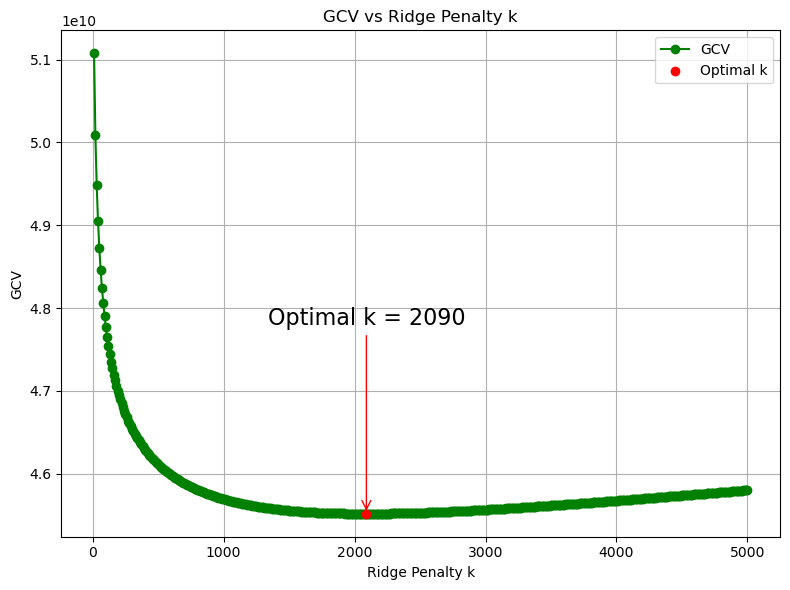

In [118]:
# Compute GCV
gcv_values = compute_GCV_ridge(X_regressor = X_scaled_std_scal_single_line, 
                                   y_dependent = y_single_sol, 
                                   k_values    = ridge_penalty_param)

# Plot GCV vs k
plot_GCV_ridge(k_values = ridge_penalty_param, 
               gcv_list = gcv_values)

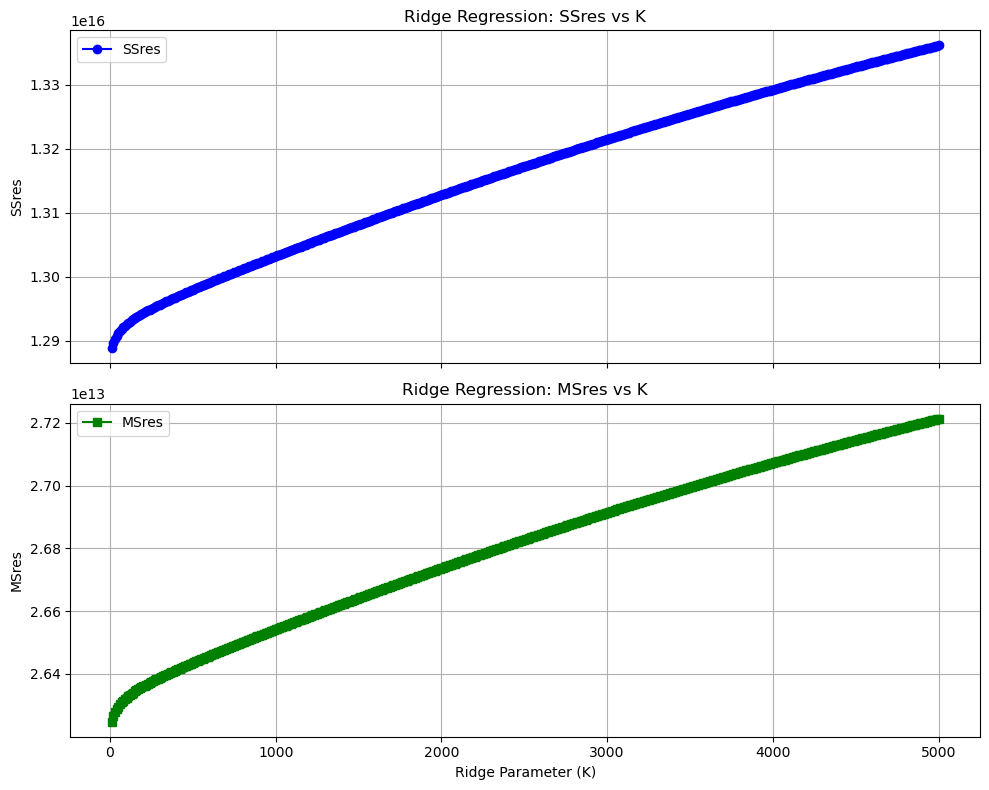

In [119]:
def ridge_ss_ms(X_regressor: np.ndarray, y_dependent_variable: pd.DataFrame, k_list: list) -> pd.DataFrame:
    """
    Calculate Residual Sum of Squares (SS_res) and Residual Mean Square (MS_res)
    for ridge regression given X, y, and a list of ridge parameters k.
    
    Parameters:
    -----------
    X_regressor : np.ndarray
        Design matrix of predictors (n x p).
    y_dependent_variable : pd.DataFrame
        Response vector (n x 1).
    k_list : list
        List of ridge penalty values (k).
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns:
        - K (ridge parameter)
        - SSres (residual sum of squares)
        - MSres (residual mean square)
    """
    # Convert y to numpy array
    y = y_dependent_variable.values.flatten()
    
    # Precompute X'X and X'y
    XtX = X_regressor.T @ X_regressor
    Xty = X_regressor.T @ y
    
    n, p = X_regressor.shape
    
    results = []
    
    for k in k_list:
        # Ridge estimator: beta_R = (X'X + kI)^(-1) X'y
        beta_r = np.linalg.inv(XtX + k * np.eye(XtX.shape[0])) @ Xty
        
        # Residuals: y - X beta_R
        residuals = y - X_regressor @ beta_r
        
        # Residual sum of squares: r'r
        ss_res = residuals.T @ residuals
        
        # Residual mean square: SS_res / (n - p)
        ms_res = ss_res / (n - p)
        
        results.append([k, ss_res, ms_res])
    
    # Create DataFrame
    df_ss_ms = pd.DataFrame(results, columns=["K", "SSres", "MSres"])
    
    return df_ss_ms

def plot_ss_ms(df____: pd.DataFrame):
    """
    Plot K vs SSres and MSres from the DataFrame using subplots (2 rows, 1 column).
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot SSres on the first subplot
    axes[0].plot(df____["K"], df____["SSres"], marker="o", color="blue", label="SSres")
    axes[0].set_ylabel("SSres")
    axes[0].set_title("Ridge Regression: SSres vs K")
    axes[0].legend()
    axes[0].grid(True)

    # Plot MSres on the second subplot
    axes[1].plot(df____["K"], df____["MSres"], marker="s", color="green", label="MSres")
    axes[1].set_xlabel("Ridge Parameter (K)")
    axes[1].set_ylabel("MSres")
    axes[1].set_title("Ridge Regression: MSres vs K")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


ridge_penalty_param = list(range(10, 5001, 10))

df_results_ss_ms = ridge_ss_ms(X_regressor = X_scaled_std_scal_single_line, 
                         y_dependent_variable = y_single_sol, 
                         k_list    = ridge_penalty_param)

plot_ss_ms(df____=df_results_ss_ms)

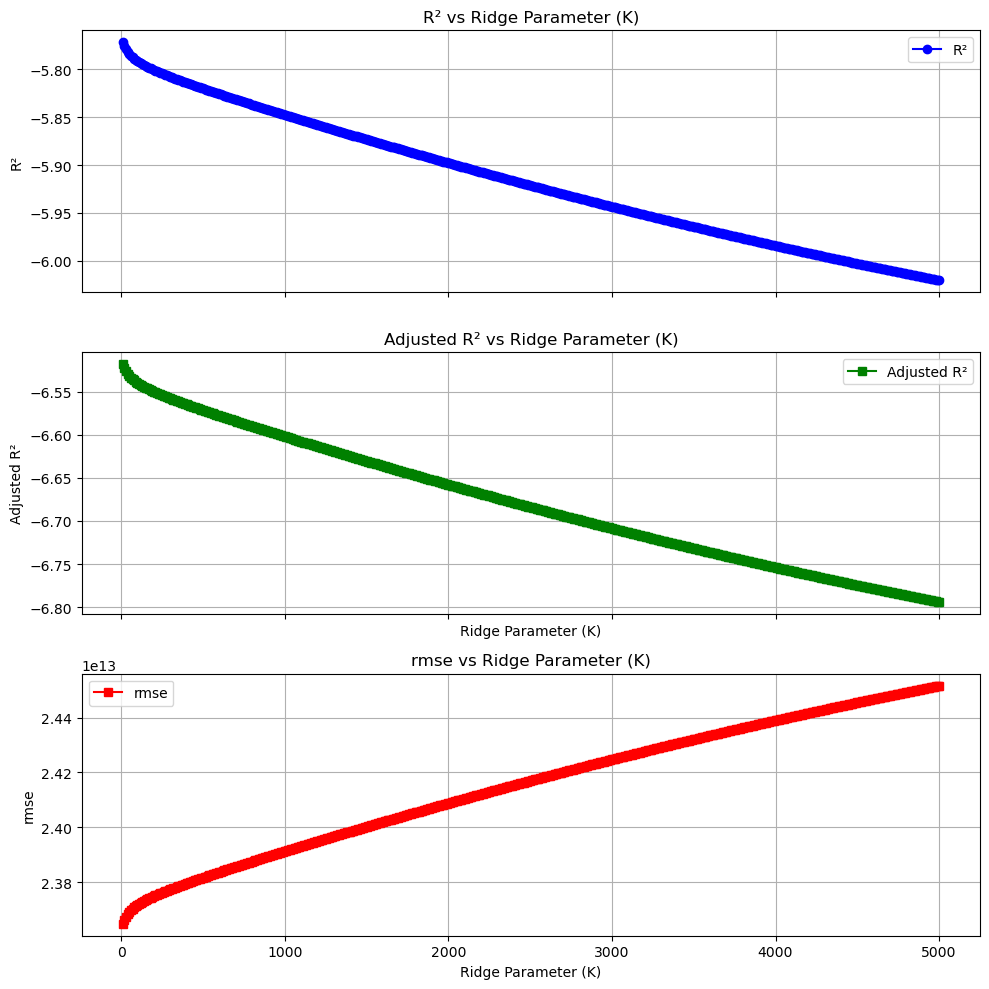

In [120]:
def ridge_rsquare(
    X_regressor: np.ndarray,
    y_dependent_variable: pd.DataFrame,
    k_list: list
) -> pd.DataFrame:
    """
    Calculate R² and Adjusted R² for ridge regression across given k_list.
    Returns a DataFrame with columns ["K", "RSqr", "AdjRsqr"].
    Also plots K vs R² and Adjusted R² in subplots (2 rows, 1 column).
    """
    y = y_dependent_variable.values.flatten()
    n, p = X_regressor.shape
    
    results = []
    
    # Total Sum of Squares (SST)
    SS_tot = np.dot(y, y) - (np.sum(y) ** 2) / n
    
    for k in k_list:
        # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
        XtX = X_regressor.T @ X_regressor
        XtY = X_regressor.T @ y
        beta_hat = np.linalg.inv(XtX + k * np.eye(p)) @ XtY
        
        # Residuals and SSres
        y_hat = X_regressor @ beta_hat # y_hat Fitted Values
        residuals = y - y_hat
        SS_res = residuals.T @ residuals
        
        #RMSE
        rmse = mean_squared_error(y, y_hat)
        
        # R²
        R2 = 1 - SS_res / SS_tot
        
        # Adjusted R²
        AdjR2 = 1 - ((1 - R2) * (n - 1)) / (n - p - 1)
        
        results.append([k, R2, AdjR2, rmse])
    
    # Convert to DataFrame
    df_rsqr_results = pd.DataFrame(results, columns=["K", "RSqr", "AdjRsqr","rmse"])
    return df_rsqr_results

def plot_rsqr_adj_rsqr_vs_k(_df____):    
    # Plotting
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    # R² plot
    axes[0].plot(_df____["K"], _df____["RSqr"], marker="o", color="blue", label="R²")
    axes[0].set_ylabel("R²")
    axes[0].set_title("R² vs Ridge Parameter (K)")
    axes[0].legend()
    axes[0].grid(True)
    
    # Adjusted R² plot
    axes[1].plot(_df____["K"], _df____["AdjRsqr"], marker="s", color="green", label="Adjusted R²")
    axes[1].set_xlabel("Ridge Parameter (K)")
    axes[1].set_ylabel("Adjusted R²")
    axes[1].set_title("Adjusted R² vs Ridge Parameter (K)")
    axes[1].legend()
    axes[1].grid(True)
    
    # rms plot
    axes[2].plot(_df____["K"], _df____["rmse"], marker="s", color="red", label="rmse")
    axes[2].set_xlabel("Ridge Parameter (K)")
    axes[2].set_ylabel("rmse")
    axes[2].set_title("rmse vs Ridge Parameter (K)")
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()    
    return 

df_results_r_sqr = ridge_rsquare(X_regressor = X_scaled_std_scal_single_line, 
                         y_dependent_variable = y_single_sol, 
                         k_list    = ridge_penalty_param)

plot_rsqr_adj_rsqr_vs_k(_df____=df_results_r_sqr)

#### Plot  fitted values Vs residuals


In [121]:
def ridge_residuals_fitted(
    X_regressor: np.ndarray,
    y_dependent_variable: pd.DataFrame,
    k_value: float
) -> pd.DataFrame:
    """
    Calculate fitted values and residuals using ridge regression formula.      
    Returns
    -------
    pd.DataFrame
        DataFrame with columns named as integer part of k_value,
        containing fitted values and residuals.
    """
    y = y_dependent_variable.values.flatten()
    n, p = X_regressor.shape
    
    # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
    XtX = X_regressor.T @ X_regressor
    XtY = X_regressor.T @ y
    beta_hat = np.linalg.inv(XtX + k_value * np.eye(p)) @ XtY
    
    # Fitted values and residuals
    fitted_vals = X_regressor @ beta_hat
    residuals = y - fitted_vals
    
    # Store in DataFrame
    col_name = f'{(int(k_value))}'  # keep integer part only
    df_results = pd.DataFrame({
        f"{col_name}_fitted": fitted_vals,
        f"{col_name}_residuals": residuals
    })    
    return df_results

# [174.614, 2090,2231.6829,2140,2220, 2230,2240]
Residula_Vs_Fitted = ridge_residuals_fitted(X_regressor = X_scaled_std_scal_single_line, 
                         y_dependent_variable = y_single_sol, 
                         k_value    = 2240.01)


Residula_Vs_Fitted.columns

Index(['2240_fitted', '2240_residuals'], dtype='object')

Text(0.5, 1.0, 'Residuals vs Fitted Values Ridge Regression')

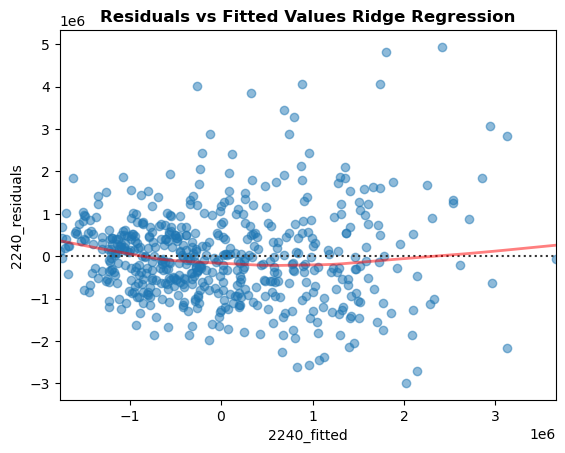

In [122]:
# correct below code
fig, ax = plt.subplots()
sns.residplot(
    data=Residula_Vs_Fitted,
    x='2240_fitted',
    y='2240_residuals',
    lowess=True,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "lw": 2, "alpha": 0.5},
    ax=ax
)

# annotations
y_predict___ = Residula_Vs_Fitted['2240_fitted'].values
residual___  = Residula_Vs_Fitted['2240_residuals'].values
residual_abs = np.abs(residual___)

abs_resid = np.argsort(residual_abs)[::-1]   # sort descending
abs_resid_top_3 = abs_resid[:3]

for i in abs_resid_top_3:
    ax.annotate(f'{i}', xy=(y_predict___[i], residual___[i]), color="C3")

ax.set_title("Residuals vs Fitted Values Ridge Regression", fontweight="bold")

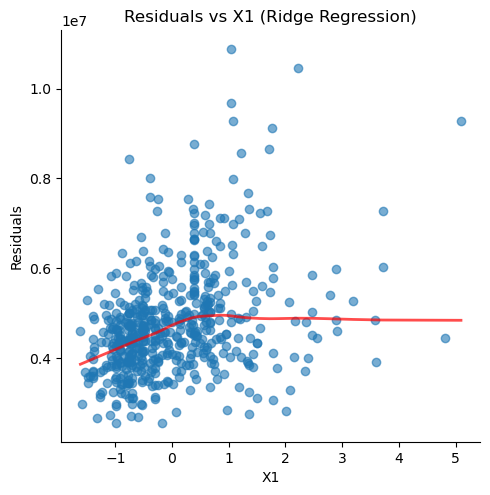

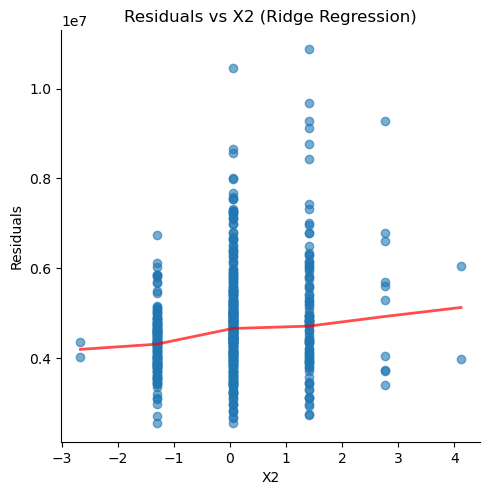

c:\Users\TODO\anaconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


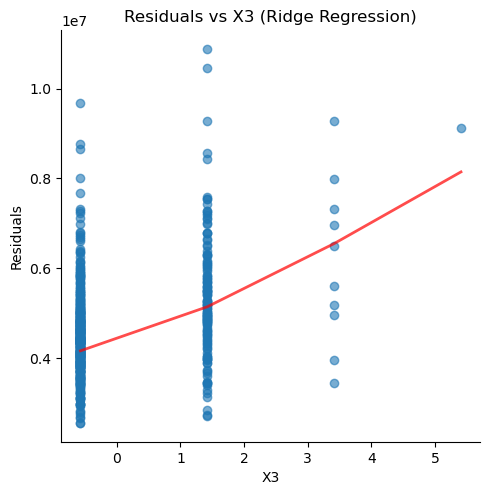

In [123]:
def plot_residuals_vs_predictors_lmplot(
    X_regressor: np.ndarray,
    residuals: pd.Series,
    predictor_names=None,
    model_name: str = "Ridge Regression"
):
    """
    Plot residuals vs each predictor using seaborn lmplot with fitted line.
    
    Parameters
    ----------
    X_regressor : np.ndarray
        Predictor matrix (n x p).
    residuals : pd.Series
        Residuals from regression (y - y_hat).
    predictor_names : list, optional
        Names of predictors. If None, auto-generates X1, X2, ...
    model_name : str
        Title prefix for plots.
    """
    # Convert predictors into DataFrame
    if predictor_names is None:
        predictor_names = [f"X{i+1}" for i in range(X_regressor.shape[1])]
    df = pd.DataFrame(X_regressor, columns=predictor_names)
    residuals = residuals[~np.isnan(residuals)]
    df["Residuals"] = residuals.values
    
    # Plot each predictor vs residuals
    for col in predictor_names:
        sns.lmplot(
            data=df,
            x=col,
            y="Residuals",
            lowess=True,   # locally weighted smoothing line
            scatter_kws={"alpha": 0.6},
            line_kws={"color": "red", "lw": 2, "alpha": 0.7}
        )
        plt.title(f"Residuals vs {col} ({model_name})")
       # plt.axhline(y=0, color="black", linestyle="--")
        plt.show()

plot_residuals_vs_predictors_lmplot(
    X_regressor = X_scaled_std_scal_single_line[:,1:4],    
    residuals = Residula_Vs_Fitted['2240_residuals'],
    model_name = "Ridge Regression"
)

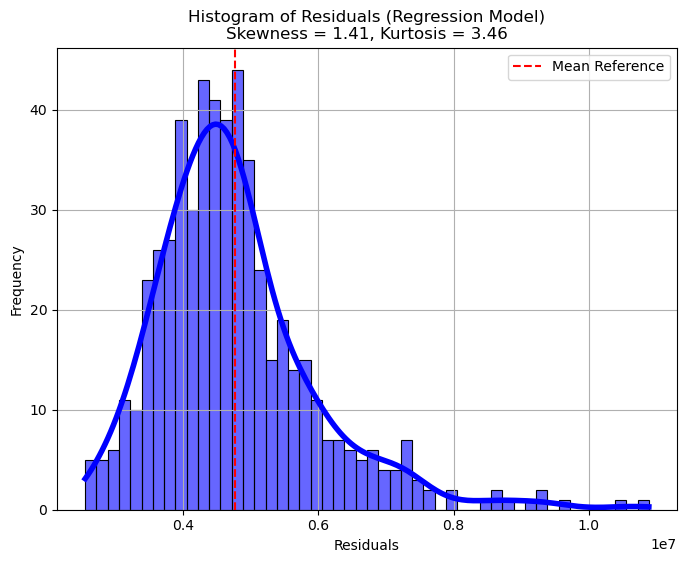

In [124]:
def plot_residuals_hist(residuals: pd.Series,bins=30 ,model_name: str = "Regression Model"):
    """
    Plot histogram of residuals using seaborn.
    
    Parameters
    ----------
    residuals : pd.Series
        Residuals from regression (y - y_hat).
    model_name : str
        Title for the plot.
    """
    skewness_val = skew(residuals, nan_policy="omit")
    kurtosis_val = kurtosis(residuals, nan_policy="omit")  # Fisher’s definition (0 = normal)

    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, bins=bins, kde=True, color="blue", alpha=0.6,
                 line_kws={"color": "red", "lw": 4}  # <-- KDE line in black
    )
    plt.axvline(x=np.mean(residuals), color="red", linestyle="--", label="Mean Reference")
    #plt.axhline(x=kurtosis_val, color="green", linestyle="--", label=f"Kurtosis = {kurtosis_val:.2f}")   

    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals ({model_name})\nSkewness = {skewness_val:.2f}, Kurtosis = {kurtosis_val:.2f}")
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_residuals_hist(residuals = Residula_Vs_Fitted['2240_residuals'],bins=50, model_name = "Regression Model")

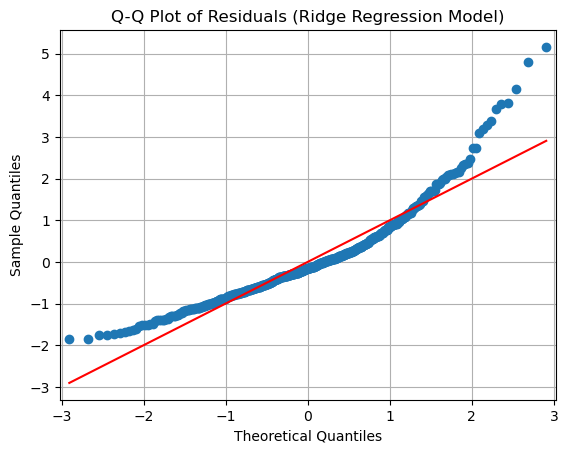

In [125]:
def plot_residuals_qq(residuals: pd.Series,lines = '45', model_name: str = "Ridge Regression Model"):
    """
    Plot Q-Q plot of residuals using statsmodels.
    
    Parameters
    ----------
    residuals : pd.Series
        Residuals from regression (y - y_hat).
    model_name : str
        Title for the plot.
    """
    fig = sm.qqplot(residuals, line=lines, fit=True)
    plt.title(f"Q-Q Plot of Residuals ({model_name})")
    plt.grid(True)
    plt.show()

plot_residuals_qq(residuals=Residula_Vs_Fitted['2240_residuals'],lines = 's')

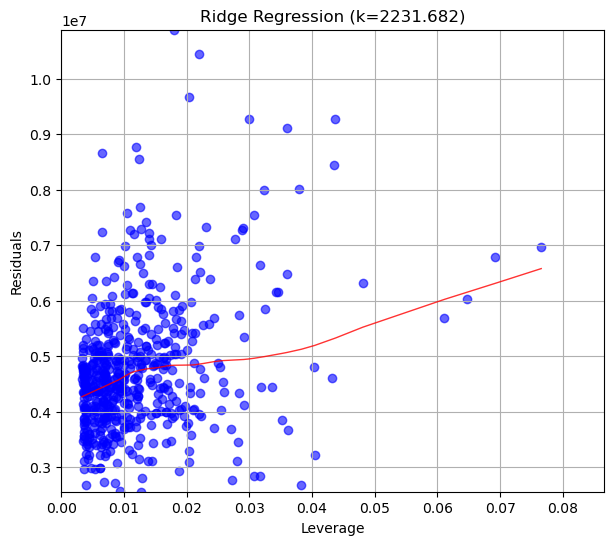

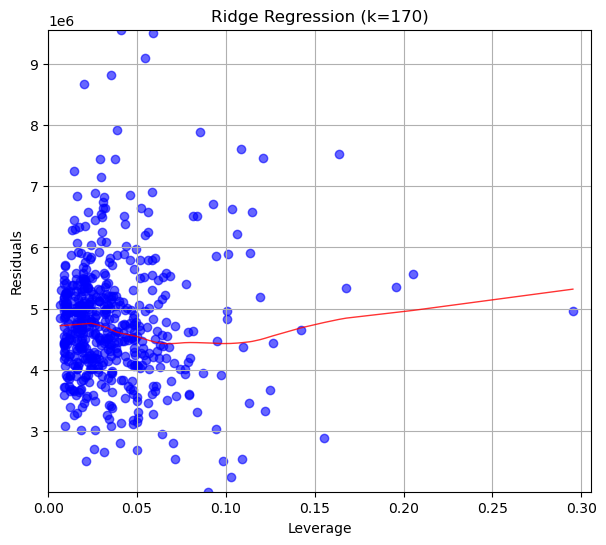

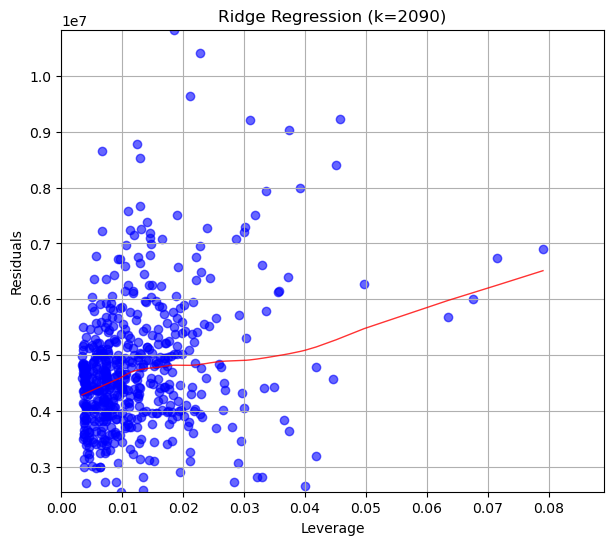

In [126]:
def residuals_vs_leverage_plot(X_regressor: np.ndarray, 
                               y_dependent: pd.Series, 
                               k: float, 
                               model_name: str = "Ridge Regression"):
    """
    Plot Residuals vs. Leverage for a single ridge penalty value (k).
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape

    # Hat matrix for ridge
    H_k = ridge_hat_matrix(X_regressor = X_regressor, k = k)

    # Fitted values and residuals
    y_hat = H_k @ y
    residuals = (y - y_hat).flatten()

    # Leverage = diagonal of hat matrix
    leverage = np.diag(H_k)

    # Plot residuals vs leverage
    plt.figure(figsize=(7, 6))
    plt.scatter(leverage, residuals, alpha=0.6, color="blue")
    sns.regplot(
            x=leverage,
            y=residuals,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={"color": "red", "lw": 1, "alpha": 0.8},
        )
    plt.axhline(0, ls="dotted", color="black", lw=1.25)
    plt.xlim(0, max(leverage) + 0.01)
    plt.ylim(min(residuals) - 0.1, max(residuals) + 0.1)
    plt.xlabel("Leverage")
    plt.ylabel("Residuals")
    plt.title(f"{model_name} (k={k})")
    plt.grid(True)
    plt.show()

k_list_ = [174.614, 2090, 2231.6829, 2140, 2220, 2230,2240,2300]
residuals_vs_leverage_plot(X_regressor = X_scaled_std_scal_single_line, 
                               y_dependent = y_single_sol, 
                               k = 2231.682,
                               )

residuals_vs_leverage_plot(X_regressor = X_scaled_std_scal_single_line, 
                               y_dependent = y_single_sol, 
                               k = 170,
                               )

residuals_vs_leverage_plot(X_regressor = X_scaled_std_scal_single_line, 
                               y_dependent = y_single_sol, 
                               k = 2090,
                               )

#### Modelsd validations
Single and two line solutions
Cross validations single line solutions and learing curve

In [127]:
def ridge_regression_cv(Xregressor, y_dependent, k, k_val):
    """
    Perform ridge regression.
    Xregressor: Feature matrix (n_samples x n_features)
    y: Target vector (n_samples,)
    k_val: Regularization parameter (lambda)
    Returns: Coefficient vector beta
    """
    n_features = Xregressor.shape[1]
    I = np.eye(n_features)
    # Ridge estimator: (X'X + λI)^(-1) X'y
    beta__ = np.linalg.inv(Xregressor.T @ Xregressor + k_val * I) @ (Xregressor.T @ y_dependent)
    return beta__

def k_fold_cross_validation(Xregressor, y_dependent, k_val, k_fold=5):
    """
    Perform k-fold cross-validation for ridge regression.
    Xregressor: Feature matrix
    y: Target vector
    k_val: Regularization parameter
    k_fold: Number of folds
    Returns: Average mean squared error across folds
    """
    n_samples = Xregressor.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    fold_size = n_samples // k_fold
    mse_scores = []
    
    for i in range(k_fold):
        # Split indices into train/test
        test_idx = indices[i*fold_size:(i+1)*fold_size]
        train_idx = np.setdiff1d(indices, test_idx)
        
        X_train__, y_train__ = Xregressor[train_idx], y_dependent[train_idx]
        X_test__, y_test__ = Xregressor[test_idx], y_dependent[test_idx]
        
        # Fit ridge regression
        betaR__ = ridge_regression_cv(X_train__, y_train__, k_fold, k_val)
        
        # Predict
        y_pred = X_test__ @ betaR__
        
        # Compute mean squared error
        mse = np.mean((y_test__ - y_pred)**2)
        mse_scores.append(mse)
    
    return np.mean(mse_scores)
k_list_ = [174.614, 2090, 2231.6829, 2140, 2220, 2230,2240]
avg_mse_list = []
for ik in k_list_:
    avg_mse = k_fold_cross_validation(Xregressor = X_scaled_std_scal_single_line, 
                                  y_dependent = np.asarray(y_single_sol).reshape(-1, 1), 
                                  k_val = ik, 
                                  k_fold=5
                                  )
    avg_mse_list.append(avg_mse)

print(f"k val {ik} Average MSE across folds: {avg_mse:.4f}")    
# After filling avg_mse_list
min_mse = min(avg_mse_list)                          # find minimum MSE
min_index = avg_mse_list.index(min_mse)              # index of minimum MSE
best_k = k_list_[min_index]                          # corresponding k value

print(f"Minimum MSE: {min_mse:.4f} at k = {best_k}")


k val 2240 Average MSE across folds: 24726999110878.6328
Minimum MSE: 24701874315023.0469 at k = 2090


Getting same Ridge trace

(54, 500)


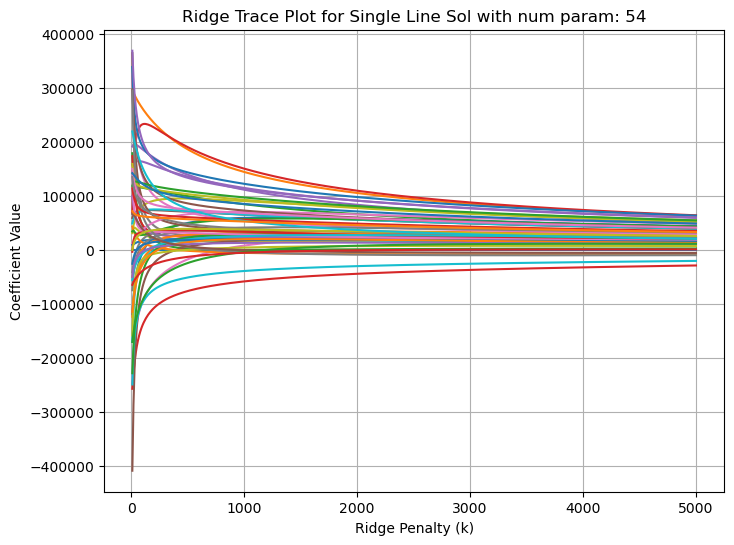

In [128]:
ridge_penalty_param = [float(x) for x in range(10, 5001, 10)]
coeffs__ = []

for alpha in ridge_penalty_param:
    ridge_model_2 = Ridge(alpha=alpha, solver='svd', random_state=42)
    ridge_model_2.fit(X_scaled_std_scal_single_line, y_single_sol)
    coeffs__.append(ridge_model_2.coef_.ravel())  # flatten to 1D

# Convert to DataFrame: rows = features, cols = alphas
coeffs_df = pd.DataFrame(np.array(coeffs__).T, columns=ridge_penalty_param)

print(coeffs_df.shape)   # (n_features, n_alphas)
#print(coeffs_df.head())

plot_ridge_trace(riddge_coff_data = coeffs_df,
                 k_values = ridge_penalty_param)

In [129]:
from sklearn.linear_model import RidgeCV

# Define penalty parameters
ridge_penalty_param = [float(x) for x in range(10, 5000, 10)]

# RidgeCV with 5-fold cross-validation
ridge_cv_model = RidgeCV(alphas=ridge_penalty_param, cv=5, scoring='neg_mean_squared_error')

# Fit the model
ridge_cv_model.fit(X_scaled_std_scal_single_line, y_single_sol)

# Best alpha and best score
print(f"Best alpha: {ridge_cv_model.alpha_}")
print(f"Best score (neg MSE): {ridge_cv_model.best_score_:.4f}")


Best alpha: 10.0
Best score (neg MSE): -2084133204444.4973


Write reason for n conflict result .e.
why statical result not math with classical ridge analysis